In [15]:
import os
import rasterio
import numpy as np
from PIL import Image
import ee
import geemap
import random
import json
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split, ConcatDataset
from torchvision import transforms
import torchvision.transforms.functional as TF
import matplotlib.pyplot as plt

In [ ]:

def converter_dataset(pasta_origem, pasta_destino, eh_mascara=False):
    os.makedirs(pasta_destino, exist_ok=True)
    arquivos = [f for f in os.listdir(pasta_origem) if f.endswith('.tif')]
    
    print(f"Convertendo {len(arquivos)} arquivos de {pasta_origem}...")

    for arquivo in arquivos:
        caminho_in = os.path.join(pasta_origem, arquivo)
        caminho_out = os.path.join(pasta_destino, arquivo.replace('.tif', '.png'))
        
        with rasterio.open(caminho_in) as src:
            if eh_mascara:
                data = src.read(1)
                data = (data * 255).astype(np.uint8)
                img = Image.fromarray(data)
            else:
                data = src.read([1, 2, 3]).transpose(1, 2, 0)
                
                p2, p98 = np.percentile(data, (2, 98))
                data_norm = np.clip((data - p2) / (p98 - p2) * 255, 0, 255).astype(np.uint8)
                img = Image.fromarray(data_norm)
            
            img.save(caminho_out)

converter_dataset('dataset/images', 'dataset_final/images', eh_mascara=False)

converter_dataset('dataset/masks', 'dataset_final/masks', eh_mascara=True)


Convertendo 4 arquivos de dataset/images...
Convertendo 4 arquivos de dataset/masks...
Conversão concluída! Agora você tem um dataset PNG pronto para a U-Net.


In [16]:
#===================================
# 2 PistasDatase
#==================================

class PistasDataset(Dataset):
    def __init__(self, image_dir, mask_dir, augment=False):
        self.image_dir = image_dir
        self.mask_dir = mask_dir
        self.images = sorted([f for f in os.listdir(image_dir) if f.endswith('.png')])
        self.masks = sorted([f for f in os.listdir(mask_dir) if f.endswith('.png')])
        self.augment = augment

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img_path = os.path.join(self.image_dir, self.images[idx])
        mask_path = os.path.join(self.mask_dir, self.masks[idx])

        image = Image.open(img_path).convert("RGB")
        mask = Image.open(mask_path).convert("L")

        # 1. Redimensionamento padrão (Sempre acontece)
        image = TF.resize(image, (256, 256))
        mask = TF.resize(mask, (256, 256))

        # 2. Data Augmentation (Opcional baseado no parâmetro augment)
        if self.augment:
            angle = random.uniform(0, 360)
            image = TF.rotate(image, angle)
            mask = TF.rotate(mask, angle, interpolation=transforms.InterpolationMode.NEAREST)

            if random.random() > 0.5:
                image = TF.hflip(image)
                mask = TF.hflip(mask)
            
            if random.random() > 0.5:
                image = TF.vflip(image)
                mask = TF.vflip(mask)

        image = TF.to_tensor(image)
        mask = TF.to_tensor(mask)
        mask = (mask > 0.5).float()

        return image, mask


def get_doubled_dataset(img_dir, mask_dir):
    dataset_original = PistasDataset(img_dir, mask_dir, augment=False)
    
    dataset_aumentado = PistasDataset(img_dir, mask_dir, augment=True)
    
    dataset_final = ConcatDataset([dataset_original, dataset_aumentado])
    
    return dataset_final

In [23]:
#===================================
# 3: preparação do dataloader
#==================================

dataset = PistasDataset('dataset/images', 'dataset/masks')

train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size

train_dataset, val_dataset = random_split(dataset, [train_size, val_size])

train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=8, shuffle=False)

print(f"Dados de treino: {len(train_dataset)}, dados de validação: {len(val_dataset)}")

Dados de treino: 3, dados de validação: 1


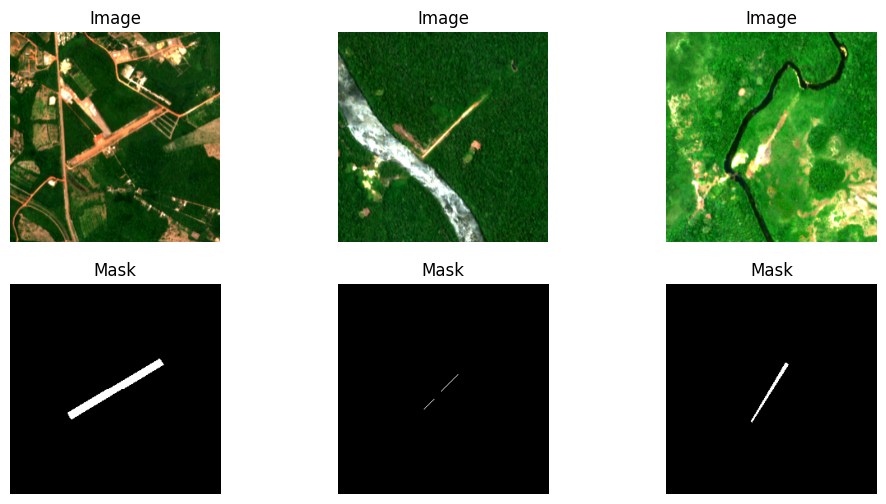

In [24]:
#===================================
# Mostrar 1 batch
#==================================

images, masks = next(iter(train_loader))

plt.figure(figsize=(12,6))
for i in range(len(images)):
    plt.subplot(2, len(images), i+1)
    plt.imshow(images[i].permute(1, 2, 0))
    plt.title("Image")
    plt.axis("off")

    plt.subplot(2, len(images), i+1+len(images))
    plt.imshow(masks[i].squeeze(), cmap="gray")
    plt.title("Mask")
    plt.axis("off")

In [ ]:
class UNet(nn.Module):
    def __init__(self):
        super(UNet, self).__init__()

        def conv_block(in_channels, out_channels):
            return nn.Sequential(
                nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1, stride=1, bias=False),
                nn.BatchNorm2d(out_channels),
                nn.ReLU(inplace=True),
                nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1, stride=1, bias=False),
                nn.BatchNorm2d(out_channels),
                nn.ReLU(inplace=True),
            )
        
        self.enc1 = conv_block(3, 64)
        self.enc2 = conv_block(64, 128)
        self.enc3 = conv_block(128, 256)
        self.enc4 = conv_block(256, 512)

        self.pool = nn.MaxPool2d(2)


In [10]:
ee.Initialize(project="desafio-solved")

municipios = ee.FeatureCollection("FAO/GAUL/2015/level2")

lista_municipios = [
    'Altamira', 'Anapu', 'Brasil Novo', 'Medicilandia',
    'Pacaja', 'Senador Jose Porfirio', 'Uruara', 'Vitoria do Xingu',
    'Itaituba', 'Aveiro', 'Jacareacanga', 'Novo Progresso',
    'Ruropolis', 'Trairao'
]

sudoeste = municipios.filter(ee.Filter.inList("ADM2_NAME", lista_municipios))

roi = sudoeste.geometry()

colecao = (ee.ImageCollection('COPERNICUS/S2_SR_HARMONIZED')
    .filterBounds(roi)
    .filterDate('2023-01-01', '2023-12-31')
    .filter(ee.Filter.lt('CLOUDY_PIXEL_PERCENTAGE', 20)))

imagem = colecao.median().clip(roi)

mapa = geemap.Map()
mapa.centerObject(roi, 7)

mapa.addLayer(imagem, {
    'bands': ['B4', 'B3', 'B2'],
    'min': 0,
    'max': 3000
}, 'Sudoeste do Pará')

mapa


Map(center=[-5.915113179729727, -54.909147137270836], controls=(WidgetControl(options=['position', 'transparen…